In [25]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt


from synthetic_simulator import NetworkSimulator


def build_transition_batches(time_series_data, n_samples=100, n_timepoints=8, rng=0, pick_mode="first"):

    N, T, G = time_series_data.shape
    n_s = min(n_samples, N)
    n_tp_max = T - 1
    n_tp = min(n_timepoints, n_tp_max)

    rng = np.random.default_rng(rng)
    sample_idx = rng.choice(N, size=n_s, replace=False)

    if pick_mode == "random":
        t_idx = rng.choice(n_tp_max, size=n_tp, replace=False)
        t_idx.sort()
    else:
        t_idx = np.arange(n_tp)

    X_t_list, X_t1_list = [], []
    for s in sample_idx:
        X = time_series_data[s]         # (T, G)
        Xt  = X[t_idx]                  # (n_tp, G)
        Xt1 = X[t_idx + 1]              # (n_tp, G)
        X_t_list.append(Xt)
        X_t1_list.append(Xt1)

    X_t  = np.vstack(X_t_list)          # (M, G) with M = n_s * n_tp
    X_t1 = np.vstack(X_t1_list)         # (M, G)
    info = dict(sample_idx=sample_idx, t_idx=t_idx, M=X_t.shape[0], G=G)
    return X_t, X_t1, info


# ------------------------------- # -------------------------------
def build_bayesian_grn_model(time_series_data, dt_obs, n_samples=100, n_timepoints=8, rng=0):
    """
    Likelihood:
        X_{t+1} | X_t, A, μ, D ~ Normal( X_t + dt_obs * A (μ - X_t), diag(D * dt_obs) )
    """
    X_t, X_t1, info = build_transition_batches(
        time_series_data, n_samples=n_samples, n_timepoints=n_timepoints, rng=rng
    )
    X_t = X_t.astype(np.float32)
    X_t1 = X_t1.astype(np.float32)
    M, G = X_t.shape

    with pm.Model() as model:
        X_t_shared  = pm.Data("X_t",  X_t)
        X_t1_shared = pm.Data("X_t1", X_t1)

     
        A_diag = pm.Normal("A_diag", mu=+1.2, sigma=0.3, shape=G)

        A_off = pm.Laplace("A_off", mu=0.0, b=2.0, shape=(G, G))
        I = np.eye(G, dtype=np.float32)
        A = pm.Deterministic("A", A_off * (1.0 - I) + pt.diag(A_diag))

        mu = pm.TruncatedNormal("mu", mu=3.0, sigma=0.5, lower=0.5, upper=6.0, shape=G)
        log_D_diag = pm.TruncatedNormal(
            "log_D_diag",
            mu=np.log(0.15), sigma=0.3,
            lower=np.log(0.01), upper=np.log(1.0),
            shape=G,
        )
        D_diag = pm.Deterministic("D_diag", pt.exp(log_D_diag))

        pred = pm.Deterministic("pred", X_t_shared + dt_obs * ((mu - X_t_shared) @ A.T))

        # Noise per gene (broadcasted across rows)
        sigma = pt.sqrt(D_diag * dt_obs)

        # Likelihood
        pm.Normal("obs", mu=pred, sigma=sigma, observed=X_t1_shared)

    return model, info


if __name__ == "__main__":
    
    num_genes = 5
    simulator = NetworkSimulator(num_genes=num_genes, network_density=0.3)

    base_dt   = 0.005
    save_every = 15
    dt_obs = base_dt * save_every  

    data = simulator.simulate(T=40.0, num_samples=500, save_every=save_every)
    # data shape: (N, T, G)
    print("Data shape:", data.shape)

    
    model, info = build_bayesian_grn_model(
        data,
        dt_obs=dt_obs,
        n_samples=20,
        n_timepoints=2,
        rng=42,
    )
    print("Batch info:", info)

    with model:
        idata = pm.sample(
            draws=2000,
            tune=1000,
            chains=4,
            target_accept=0.9,
            random_seed=123,
            #thinning
        )

    
    idata.to_netcdf("bayes_grn_results.nc")
    print("Saved posterior to bayes_grn_results.nc")


Generating 5-gene network...
6
Generated 11 regulatory relationships
Enhanced ground truth A matrix:
[[ 1.49   0.     0.836  0.     0.467]
 [ 0.     1.36   0.    -0.948  0.   ]
 [ 0.     0.     1.33   0.    -1.119]
 [ 0.     0.417  0.579  1.771  0.   ]
 [ 0.     0.     0.     0.     1.26 ]]
Simulating 500 trajectories...
Done: simulation. Data shape: (500, 534, 5)
Data shape: (500, 534, 5)
Batch info: {'sample_idx': array([373, 355,  98, 480, 419, 376,  63,  42, 316, 255, 210,  41, 225,
       417,  46, 362, 389, 212, 340, 258]), 't_idx': array([0, 1]), 'M': 40, 'G': 5}


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_diag, A_off, mu, log_D_diag]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


Saved posterior to bayes_grn_results.nc


In [9]:
import arviz as az
import matplotlib.pyplot as plt

In [26]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

try:
    idata  
except NameError:
    idata = az.from_netcdf("bayes_grn_results.nc")

posterior = idata.posterior
np.set_printoptions(precision=3, suppress=True)

def non_chain_draw_dims(xrvar):
    return [d for d in xrvar.dims if d not in ("chain", "draw")]

# For A (matrix) and vectors
A_dims = non_chain_draw_dims(posterior["A"])        # e.g., ['A_dim_0','A_dim_1']
mu_dims = non_chain_draw_dims(posterior["mu"])      # e.g., ['mu_dim_0']
D_dims = non_chain_draw_dims(posterior["D_diag"])   # e.g., ['D_diag_dim_0']

assert len(A_dims) == 2, f"Expected 2 dims for A, got {A_dims}"
G = posterior["mu"].shape[-1]

# ---- 1) Trace plots ----
# Basic traces for vector params
az.plot_trace(idata, var_names=["mu", "A_diag", "log_D_diag"])
plt.tight_layout()
plt.savefig("trace_mu_Adiag_logD.png", dpi=160)
plt.close()

# Select a few off-diagonal A entries robustly via coords=
pairs = [(0,1), (1,0), (0,2), (2,0), (1,2), (2,1)]
pairs = [(i,j) for (i,j) in pairs if i < G and j < G and i != j]

for (i, j) in pairs:
    coords = {A_dims[0]: [i], A_dims[1]: [j]}
    az.plot_trace(idata, var_names=["A"], coords=coords)
    plt.tight_layout()
    plt.savefig(f"trace_A_{i}_{j}.png", dpi=160)
    plt.close()

# ---- 2) Autocorrelation plots ----
az.plot_autocorr(idata, var_names=["mu", "A_diag", "log_D_diag"])
plt.tight_layout()
plt.savefig("autocorr_mu_Adiag_logD.png", dpi=160)
plt.close()

for (i, j) in pairs:
    coords = {A_dims[0]: [i], A_dims[1]: [j]}
    az.plot_autocorr(idata, var_names=["A"], coords=coords)
    plt.tight_layout()
    plt.savefig(f"autocorr_A_{i}_{j}.png", dpi=160)
    plt.close()

print("Saved trace/autocorr plots.")

# ---- 3) Summary + recovered parameters ----
summary = az.summary(idata, var_names=["A", "mu", "D_diag"], hdi_prob=0.95)
summary.to_csv("posterior_summary.csv")
print("\n==== Posterior summary (saved to posterior_summary.csv) ====")
print(summary.to_string())

def mean_lo_hi(xrvar):
    mean = xrvar.mean(dim=("chain","draw")).values
    std  = xrvar.std(dim=("chain", "draw")).values
    lo   = xrvar.quantile(0.025, dim=("chain","draw")).values
    hi   = xrvar.quantile(0.975, dim=("chain","draw")).values
    return mean, std, lo, hi

A_mean, A_std, A_lo, A_hi = mean_lo_hi(posterior["A"])
mu_mean, mu_std, mu_lo, mu_hi = mean_lo_hi(posterior["mu"])
D_mean, D_std, D_lo, D_hi = mean_lo_hi(posterior["D_diag"])

print("\n==== Recovered A (posterior mean) ====")
print(A_mean)
print("\nA 95% CI lower:")
print(A_lo)
print("\nA 95% CI upper:")
print(A_hi)

print("\n==== Recovered mu (posterior mean) ====")
print(mu_mean)
print("mu 95% CI by component:")
print(np.vstack([mu_lo, mu_hi]).T)

print("\n==== Recovered D_diag (posterior mean) ====")
print(D_mean)
print("D_diag 95% CI by component:")
print(np.vstack([D_lo, D_hi]).T)

# ---- 4) (Optional) Compare to ground truth if simulator is still around ----
try:
    simulator  # noqa
    print("\n==== Compare with ground-truth A ====")
    A_true = simulator.A
    print("A_true:\n", A_true)
    print("||A_mean - A_true||_F:", np.linalg.norm(A_mean - A_true))
    print("MAE:", np.mean(np.abs(A_mean - A_true)))
except Exception:
    pass

print("\nDone.")


/home/gs270/.conda/envs/pymc_env/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (60) in plot_autocorr, generating only 40 plots
  warnings.warn(


Saved trace/autocorr plots.

==== Posterior summary (saved to posterior_summary.csv) ====
            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
A[0, 0]    1.369  0.271     0.854      1.913      0.003    0.003    9100.0    5804.0    1.0
A[0, 1]    0.237  0.556    -0.880      1.319      0.006    0.006    7551.0    5916.0    1.0
A[0, 2]    0.340  0.520    -0.650      1.420      0.005    0.006    9126.0    5823.0    1.0
A[0, 3]   -0.015  0.383    -0.764      0.748      0.004    0.005    8600.0    5872.0    1.0
A[0, 4]   -0.459  0.535    -1.490      0.598      0.005    0.006    9895.0    5918.0    1.0
A[1, 0]    0.593  0.408    -0.227      1.370      0.005    0.005    7834.0    5565.0    1.0
A[1, 1]    1.261  0.251     0.799      1.777      0.002    0.003   10185.0    5996.0    1.0
A[1, 2]   -0.078  0.392    -0.895      0.653      0.004    0.004    9229.0    6125.0    1.0
A[1, 3]   -0.866  0.314    -1.483     -0.249      0.003    0.004    9592.0    5741

In [5]:
az.plot_autocorr(idata, var_names=["mu", "A_diag", "log_D_diag"], max_lag=200, combined=True)
plt.tight_layout()
plt.savefig("autocorr_mu_Adiag_logD.png", dpi=160)
plt.close()

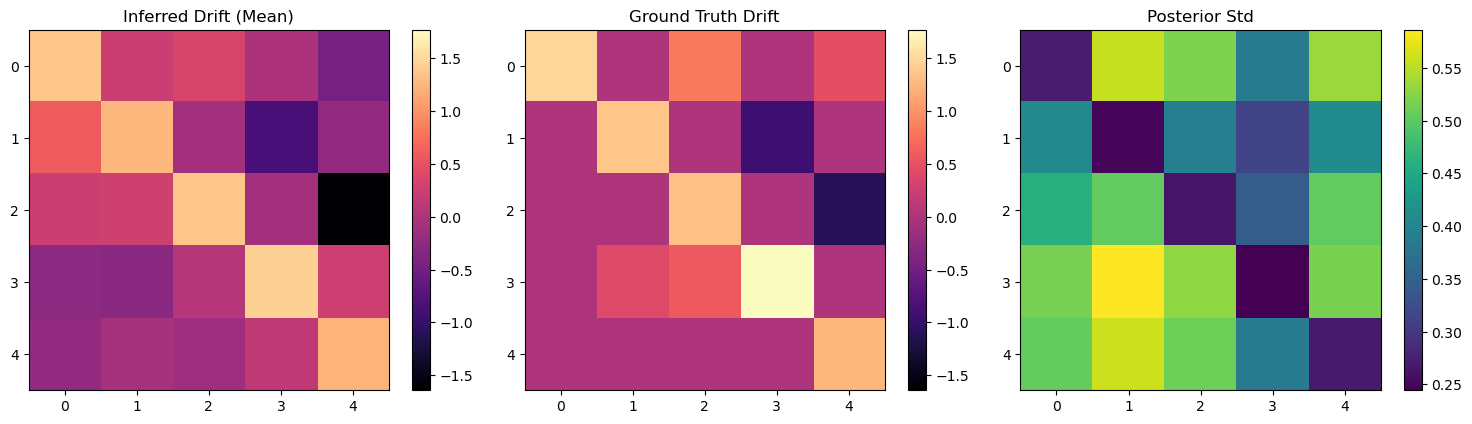

In [27]:
A = A_mean
A_std = A_std  # assuming you already computed this

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Shared color scale for mean vs ground truth
vmin = min(A.min(), simulator.A.min())
vmax = max(A.max(), simulator.A.max())

# --- Inferred Mean ---
im1 = ax1.imshow(A, cmap='magma', vmin=vmin, vmax=vmax)
ax1.set_title('Inferred Drift (Mean)')
fig.colorbar(im1, ax=ax1)

# --- Ground Truth ---
im2 = ax2.imshow(simulator.A, cmap='magma', vmin=vmin, vmax=vmax)
ax2.set_title('Ground Truth Drift')
fig.colorbar(im2, ax=ax2)

# --- Posterior Std ---
im3 = ax3.imshow(A_std, cmap='viridis')
ax3.set_title('Posterior Std')
fig.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

In [17]:
mu_mean, mu_std

(array([2.482, 2.911, 3.345, 2.614, 3.3  ]),
 array([0.174, 0.031, 0.145, 0.07 , 0.06 ]))

In [18]:
simulator.mu

array([2.541, 2.93 , 3.313, 2.591, 3.274])

In [20]:
D_mean, D_std

(array([0.132, 0.109, 0.164, 0.174, 0.137]),
 array([0.006, 0.005, 0.007, 0.007, 0.006]))

In [21]:
simulator.D

array([[0.137, 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.118, 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.179, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.188, 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.147]])